# Tomato Disease Prediction Model

Train a CNN to classify tomato leaf images into disease classes. Class folders are read from `data/tomato` (e.g. Tomato_Early_blight, Tomato_Late_blight, Tomato_Healthy). Uses ImageNet-pretrained ResNet18 and 80:20 stratified train/val split. Model saved to `export/`.

**Importing libraries**

PyTorch, torchvision, sklearn, PIL, matplotlib; device set to GPU if available.

In [2]:
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


**Config and paths**

Project root, data path `data/tomato`, export dir, image size, batch size, epochs, LR, seed. Class names are discovered from subfolders of `data/tomato`.

In [3]:
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
TOMATO_ROOT = PROJECT_ROOT / "data" / "tomato"
EXPORT_DIR = PROJECT_ROOT / "export"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-3
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Support two layouts: (1) class folders at top level, or (2) train/val with class subfolders
_subdirs = sorted([d.name for d in TOMATO_ROOT.iterdir() if d.is_dir() and not d.name.startswith(".")])
_train_dir = TOMATO_ROOT / "train"
_val_dir = TOMATO_ROOT / "val"
if "train" in _subdirs and "val" in _subdirs and _train_dir.is_dir() and _val_dir.is_dir():
    _class_subdirs = sorted([d.name for d in _train_dir.iterdir() if d.is_dir() and not d.name.startswith(".")])
    class_names = _class_subdirs if _class_subdirs else _subdirs
    USE_PRESPLIT = bool(_class_subdirs)
else:
    class_names = _subdirs
    USE_PRESPLIT = False
num_classes = len(class_names)
print("DATA_ROOT:", TOMATO_ROOT)
print("Classes:", class_names)
print("Num classes:", num_classes)
print("Using pre-split (train/val):", USE_PRESPLIT)

# Standardized export/display class names (fixed order) for tomato model
export_class_names = [
    "tomato_bacterial_spot",
    "tomato_early_blight",
    "tomato_late_blight",
    "tomato_leaf_mold",
    "tomato_septoria_leaf_spot",
    "tomato_spider_mites",
    "tomato_target_spot",
    "tomato_yellow_leaf_curl_virus",
    "tomato_mosaic_virus",
    "tomato_healthy",
]
assert len(export_class_names) == num_classes, "export_class_names must match number of dataset classes"

DATA_ROOT: e:\fyp\py\data\tomato
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Num classes: 10
Using pre-split (train/val): True


**Collect paths and labels; 80:20 stratified split**

Scan each class folder for images, then split into train/val preserving class proportions.

In [4]:
def get_paths_and_labels(root, classes, extensions=(".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG", ".webp")):
    paths, labels = [], []
    for label, name in enumerate(classes):
        folder = root / name
        if not folder.is_dir():
            continue
        for f in folder.iterdir():
            if f.is_file() and f.suffix.lower() in [e.lower() for e in extensions]:
                paths.append(str(f))
                labels.append(label)
    return paths, labels

if USE_PRESPLIT:
    train_paths, train_labels = get_paths_and_labels(_train_dir, class_names)
    val_paths, val_labels = get_paths_and_labels(_val_dir, class_names)
    paths = train_paths + val_paths
    labels = train_labels + val_labels
else:
    paths, labels = get_paths_and_labels(TOMATO_ROOT, class_names)
    if len(paths) == 0:
        _what = f"Subfolders under data/tomato: {class_names or '(none)'}. "
        raise ValueError(
            "No images found in data/tomato. " + _what +
            "Expected: (1) class subfolders with images (e.g. data/tomato/Tomato_Early_blight/*.jpg), "
            "or (2) data/tomato/train/ and data/tomato/val/ each with class subfolders containing images."
        )
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        paths, labels, test_size=0.2, stratify=labels, random_state=SEED
    )
print("Total images:", len(paths))
print("Train:", len(train_paths), "Val:", len(val_paths))

Total images: 11000
Train: 10000 Val: 1000


**Transforms and Dataset**

Train: resize, flips, color jitter, ImageNet normalize. Val: resize + normalize. Custom Dataset loads by path and applies transform.

In [5]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class TomatoDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[i]

train_ds = TomatoDataset(train_paths, train_labels, transform=train_tf)
val_ds = TomatoDataset(val_paths, val_labels, transform=val_tf)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("DataLoaders ready.")

DataLoaders ready.


**Model**

ResNet18 with ImageNet pretrained weights; final layer replaced for num_classes.

In [6]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
print("ResNet18 (pretrained), num_classes =", num_classes)

ResNet18 (pretrained), num_classes = 10


**Train and eval helpers**

One epoch train (loss + accuracy) and one epoch validation (accuracy).

In [7]:
def train_epoch(loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

**Training loop**

Run EPOCHS; save best model to export/tomato_disease_model.pt when val accuracy improves.

**Metrics: precision, recall, F1, support**

Per-class precision, recall, F1-score (grouped bar chart) and support (bar chart). Uses the same validation predictions as above.

In [8]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(train_loader)
    val_acc = eval_epoch(val_loader)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), EXPORT_DIR / "tomato_disease_model.pt")
    print(f"Epoch {epoch+1}/{EPOCHS}  loss={train_loss:.4f}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}  best={best_val_acc:.4f}")

Epoch 1/10  loss=0.4780  train_acc=0.8410  val_acc=0.7810  best=0.7810
Epoch 2/10  loss=0.2286  train_acc=0.9226  val_acc=0.8600  best=0.8600
Epoch 3/10  loss=0.2070  train_acc=0.9296  val_acc=0.9290  best=0.9290
Epoch 4/10  loss=0.1693  train_acc=0.9425  val_acc=0.9370  best=0.9370
Epoch 5/10  loss=0.1346  train_acc=0.9547  val_acc=0.9650  best=0.9650
Epoch 6/10  loss=0.1209  train_acc=0.9601  val_acc=0.9400  best=0.9650
Epoch 7/10  loss=0.0999  train_acc=0.9662  val_acc=0.9640  best=0.9650
Epoch 8/10  loss=0.0958  train_acc=0.9690  val_acc=0.9350  best=0.9650
Epoch 9/10  loss=0.0871  train_acc=0.9731  val_acc=0.9740  best=0.9740
Epoch 10/10  loss=0.0914  train_acc=0.9678  val_acc=0.9730  best=0.9740


**Save class names**

Write class_names to export/tomato_class_names.json for inference.

In [9]:
with open(EXPORT_DIR / "tomato_class_names.json", "w") as f:
    json.dump(export_class_names, f, indent=2)
print("Saved", EXPORT_DIR / "tomato_class_names.json")

Saved e:\fyp\py\export\tomato_class_names.json


**Evaluation**

Load best checkpoint, run validation set, print classification report and confusion matrix.

In [10]:
model.load_state_dict(torch.load(EXPORT_DIR / "tomato_disease_model.pt", map_location=device))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device)
        logits = model(X)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(y.numpy())

print(classification_report(all_labels, all_preds, target_names=export_class_names))
print("Confusion matrix:")
print(confusion_matrix(all_labels, all_preds))

                               precision    recall  f1-score   support

        tomato_bacterial_spot       0.98      0.92      0.95       100
          tomato_early_blight       0.97      0.97      0.97       100
           tomato_late_blight       1.00      0.97      0.98       100
             tomato_leaf_mold       0.95      1.00      0.98       100
    tomato_septoria_leaf_spot       0.95      0.97      0.96       100
          tomato_spider_mites       0.99      0.96      0.97       100
           tomato_target_spot       0.96      0.96      0.96       100
tomato_yellow_leaf_curl_virus       0.94      1.00      0.97       100
          tomato_mosaic_virus       1.00      1.00      1.00       100
               tomato_healthy       1.00      0.99      0.99       100

                     accuracy                           0.97      1000
                    macro avg       0.97      0.97      0.97      1000
                 weighted avg       0.97      0.97      0.97      1000

Con

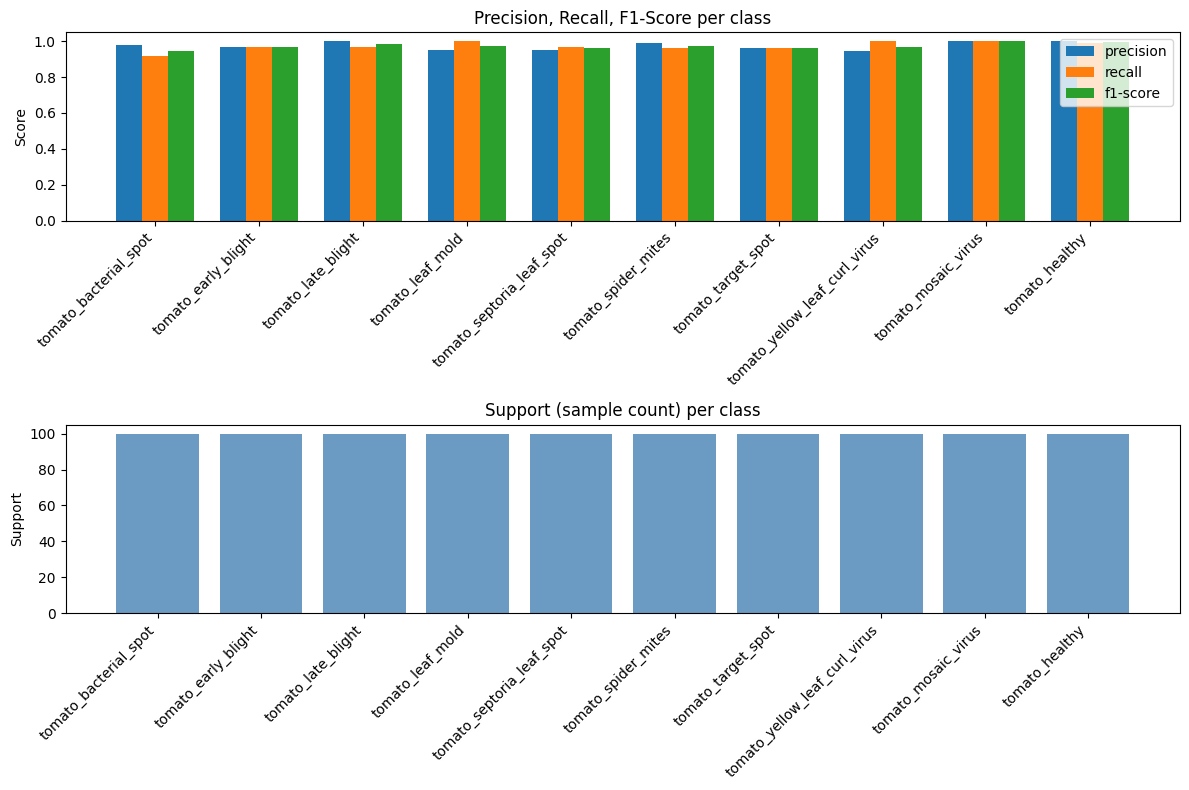

In [11]:
report_dict = classification_report(all_labels, all_preds, target_names=export_class_names, output_dict=True)
metrics = ["precision", "recall", "f1-score"]
x = np.arange(len(export_class_names))
width = 0.25

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
# Precision, recall, F1 per class
ax0 = axes[0]
for i, m in enumerate(metrics):
    vals = [report_dict[c][m] for c in export_class_names]
    ax0.bar(x + width * (i - 1), vals, width, label=m)
ax0.set_xticks(x)
ax0.set_xticklabels(export_class_names, rotation=45, ha="right")
ax0.set_ylabel("Score")
ax0.set_title("Precision, Recall, F1-Score per class")
ax0.legend()
ax0.set_ylim(0, 1.05)
# Support per class
ax1 = axes[1]
supports = [report_dict[c]["support"] for c in export_class_names]
ax1.bar(x, supports, color="steelblue", alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(export_class_names, rotation=45, ha="right")
ax1.set_ylabel("Support")
ax1.set_title("Support (sample count) per class")
plt.tight_layout()
plt.show()